# 01 — Exploratory Data Analysis

**Phase 1.2.5** of the SurfSense ML pipeline.

Covers:
- Missing-value audit
- Per-spot and per-season sample counts
- Feature distributions
- Correlation heatmap
- Synthetic label (`surf_quality_score`) distribution
- Target-vs-feature scatter for top candidates

All figures are saved to `ml/figures/eda/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Make ml/ importable when running from ml/notebooks/
repo_root = Path().resolve().parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ml.labels import compute_synthetic_score

SEED = 42
np.random.seed(SEED)

FIG_DIR = Path("../figures/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

print("figures →", FIG_DIR.resolve())

figures → /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/eda


## 1. Load data & compute synthetic label

In [2]:
df = pd.read_parquet("../data/processed/historical.parquet")

# Compute synthetic label (not stored in parquet yet)
df["surf_quality_score"] = df.apply(compute_synthetic_score, axis=1)

print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
df.head(3)

Rows: 87,720   Columns: 19


,timestamp,wave_height_m,wave_period_s,wave_direction_deg,swell_height_m,swell_period_s,swell_direction_deg,wind_wave_height_m,wind_wave_period_s,water_temp_c,wind_speed_kph,wind_direction_deg,wind_gust_kph,air_temp_c,spot_id,lat,lon,tide_height_m,surf_quality_score
0,2024-04-25 00:00:00+00:00,1.82,6.30,337,0.48,7.25,333,1.54,4.75,16.3,23.4,1,36.7,13.4,ericeira,38.9625,-9.4167,NaN,22.662444
1,2024-04-25 01:00:00+00:00,1.90,6.35,337,0.68,7.35,326,1.60,4.95,16.2,25.6,358,40.3,13.6,ericeira,38.9625,-9.4167,NaN,23.189170
2,2024-04-25 02:00:00+00:00,2.00,6.45,337,0.86,7.35,319,1.68,5.05,16.1,26.0,357,41.0,13.2,ericeira,38.9625,-9.4167,NaN,23.692237


## 2. Missing-value audit

                     n_missing  pct_missing
tide_height_m            87720       100.00
water_temp_c              1560         1.78
wind_speed_kph               0         0.00
lon                          0         0.00
lat                          0         0.00
spot_id                      0         0.00
air_temp_c                   0         0.00
wind_gust_kph                0         0.00
wind_direction_deg           0         0.00
timestamp                    0         0.00
wave_height_m                0         0.00
wind_wave_period_s           0         0.00
wind_wave_height_m           0         0.00
swell_direction_deg          0         0.00
swell_period_s               0         0.00
swell_height_m               0         0.00
wave_direction_deg           0         0.00
wave_period_s                0         0.00
surf_quality_score           0         0.00


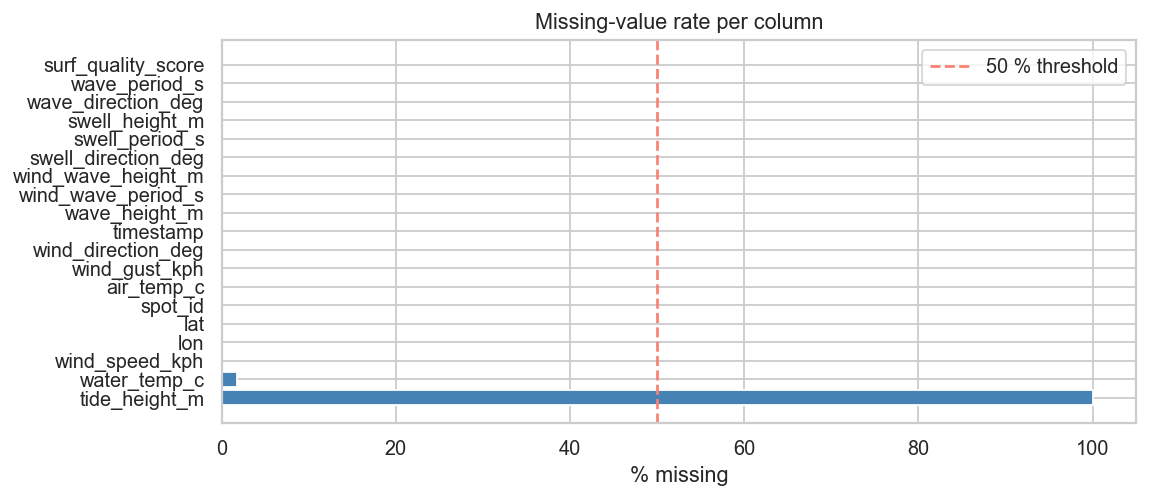

In [3]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().sum() / len(df) * 100).round(2),
}).sort_values("pct_missing", ascending=False)
print(missing.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing.index, missing["pct_missing"], color="steelblue")
ax.set_xlabel("% missing")
ax.set_title("Missing-value rate per column")
ax.axvline(50, color="salmon", lw=1.5, linestyle="--", label="50 % threshold")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "missing_values.png", bbox_inches="tight")
plt.show()

## 3. Per-spot and per-season sample counts

In [4]:
df["year"]   = df["timestamp"].dt.year
df["month"]  = df["timestamp"].dt.month
df["season"] = df["month"].map({
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM",  4: "MAM", 5: "MAM",
    6: "JJA",  7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
})

spot_counts = df["spot_id"].value_counts().rename("n_rows")
print("Per-spot counts:")
print(spot_counts.to_string())
print()

season_spot = df.groupby(["season", "spot_id"]).size().unstack(fill_value=0)
print("Per-season × per-spot:")
print(season_spot.to_string())

Per-spot counts:
spot_id
ericeira        17544
gold_coast      17544
hossegor        17544
jeffreys_bay    17544
pipeline        17544

Per-season × per-spot:
spot_id  ericeira  gold_coast  hossegor  jeffreys_bay  pipeline
season                                                         
DJF          4320        4320      4320          4320      4320
JJA          4416        4416      4416          4416      4416
MAM          4440        4440      4440          4440      4440
SON          4368        4368      4368          4368      4368


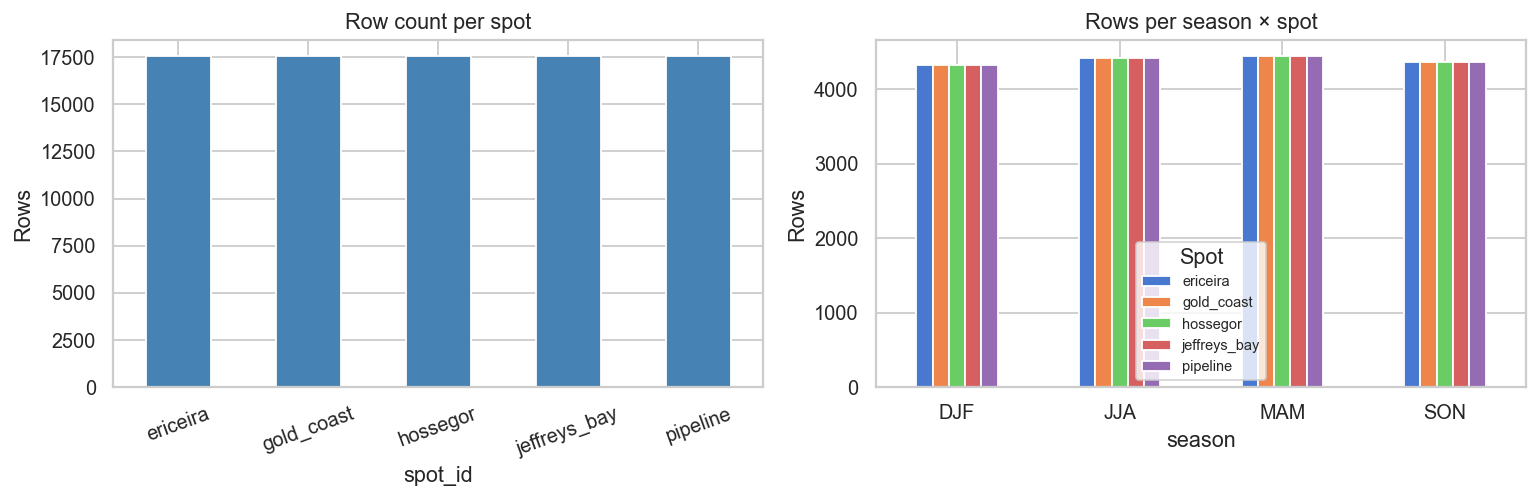

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

spot_counts.plot(kind="bar", ax=axes[0], color="steelblue", rot=20)
axes[0].set_title("Row count per spot")
axes[0].set_ylabel("Rows")

season_spot.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Rows per season × spot")
axes[1].set_ylabel("Rows")
axes[1].legend(title="Spot", fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "sample_counts.png", bbox_inches="tight")
plt.show()

## 4. Synthetic label distribution

In [6]:
target = df["surf_quality_score"]
print(target.describe().round(2))
pct_at_zero = (target == 0).mean() * 100
pct_at_100  = (target == 100).mean() * 100
print(f"\n% exactly 0  : {pct_at_zero:.1f}")
print(f"% exactly 100: {pct_at_100:.1f}")
if pct_at_zero + pct_at_100 > 50:
    print("\n⚠  MORE THAN 50 % AT EXTREMES — label formula may be degenerate")
else:
    print("\n✓  Label distribution looks healthy")

count    87720.00
mean        37.24
std         13.05
min         18.10
25%         26.01
50%         35.15
75%         45.68
max        100.00
Name: surf_quality_score, dtype: float64

% exactly 0  : 0.0
% exactly 100: 0.0

✓  Label distribution looks healthy


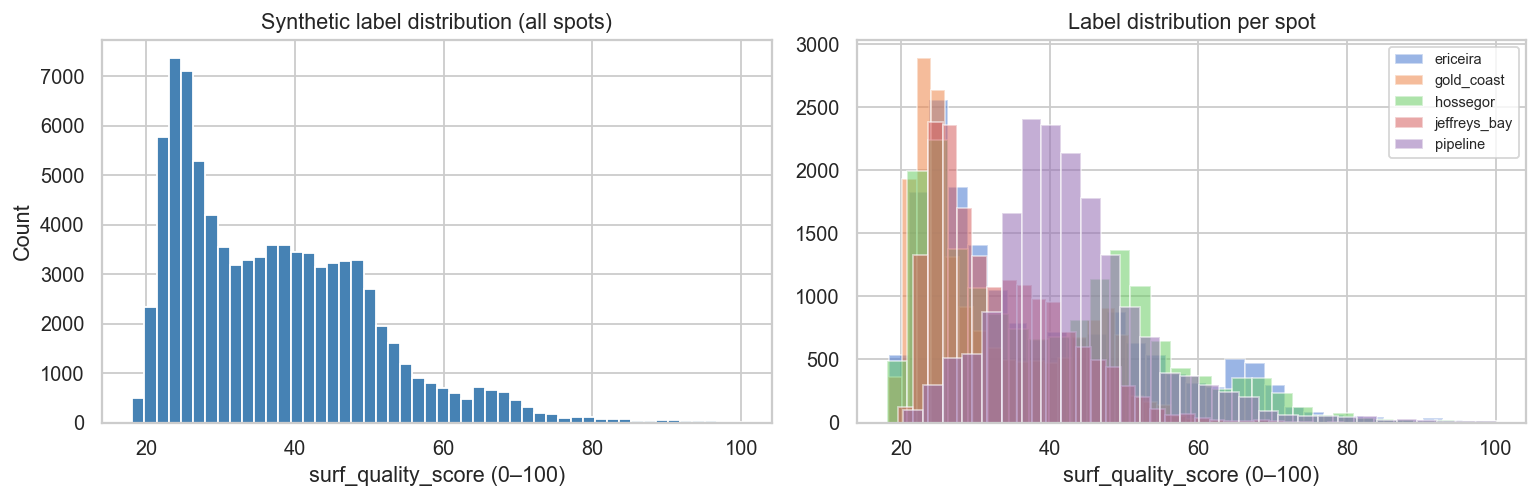

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Synthetic label distribution (all spots)")
axes[0].set_xlabel("surf_quality_score (0–100)")
axes[0].set_ylabel("Count")

for spot, grp in df.groupby("spot_id"):
    axes[1].hist(grp["surf_quality_score"], bins=30, alpha=0.55, label=spot)
axes[1].set_title("Label distribution per spot")
axes[1].set_xlabel("surf_quality_score (0–100)")
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "label_distribution.png", bbox_inches="tight")
plt.show()

## 5. Feature distributions

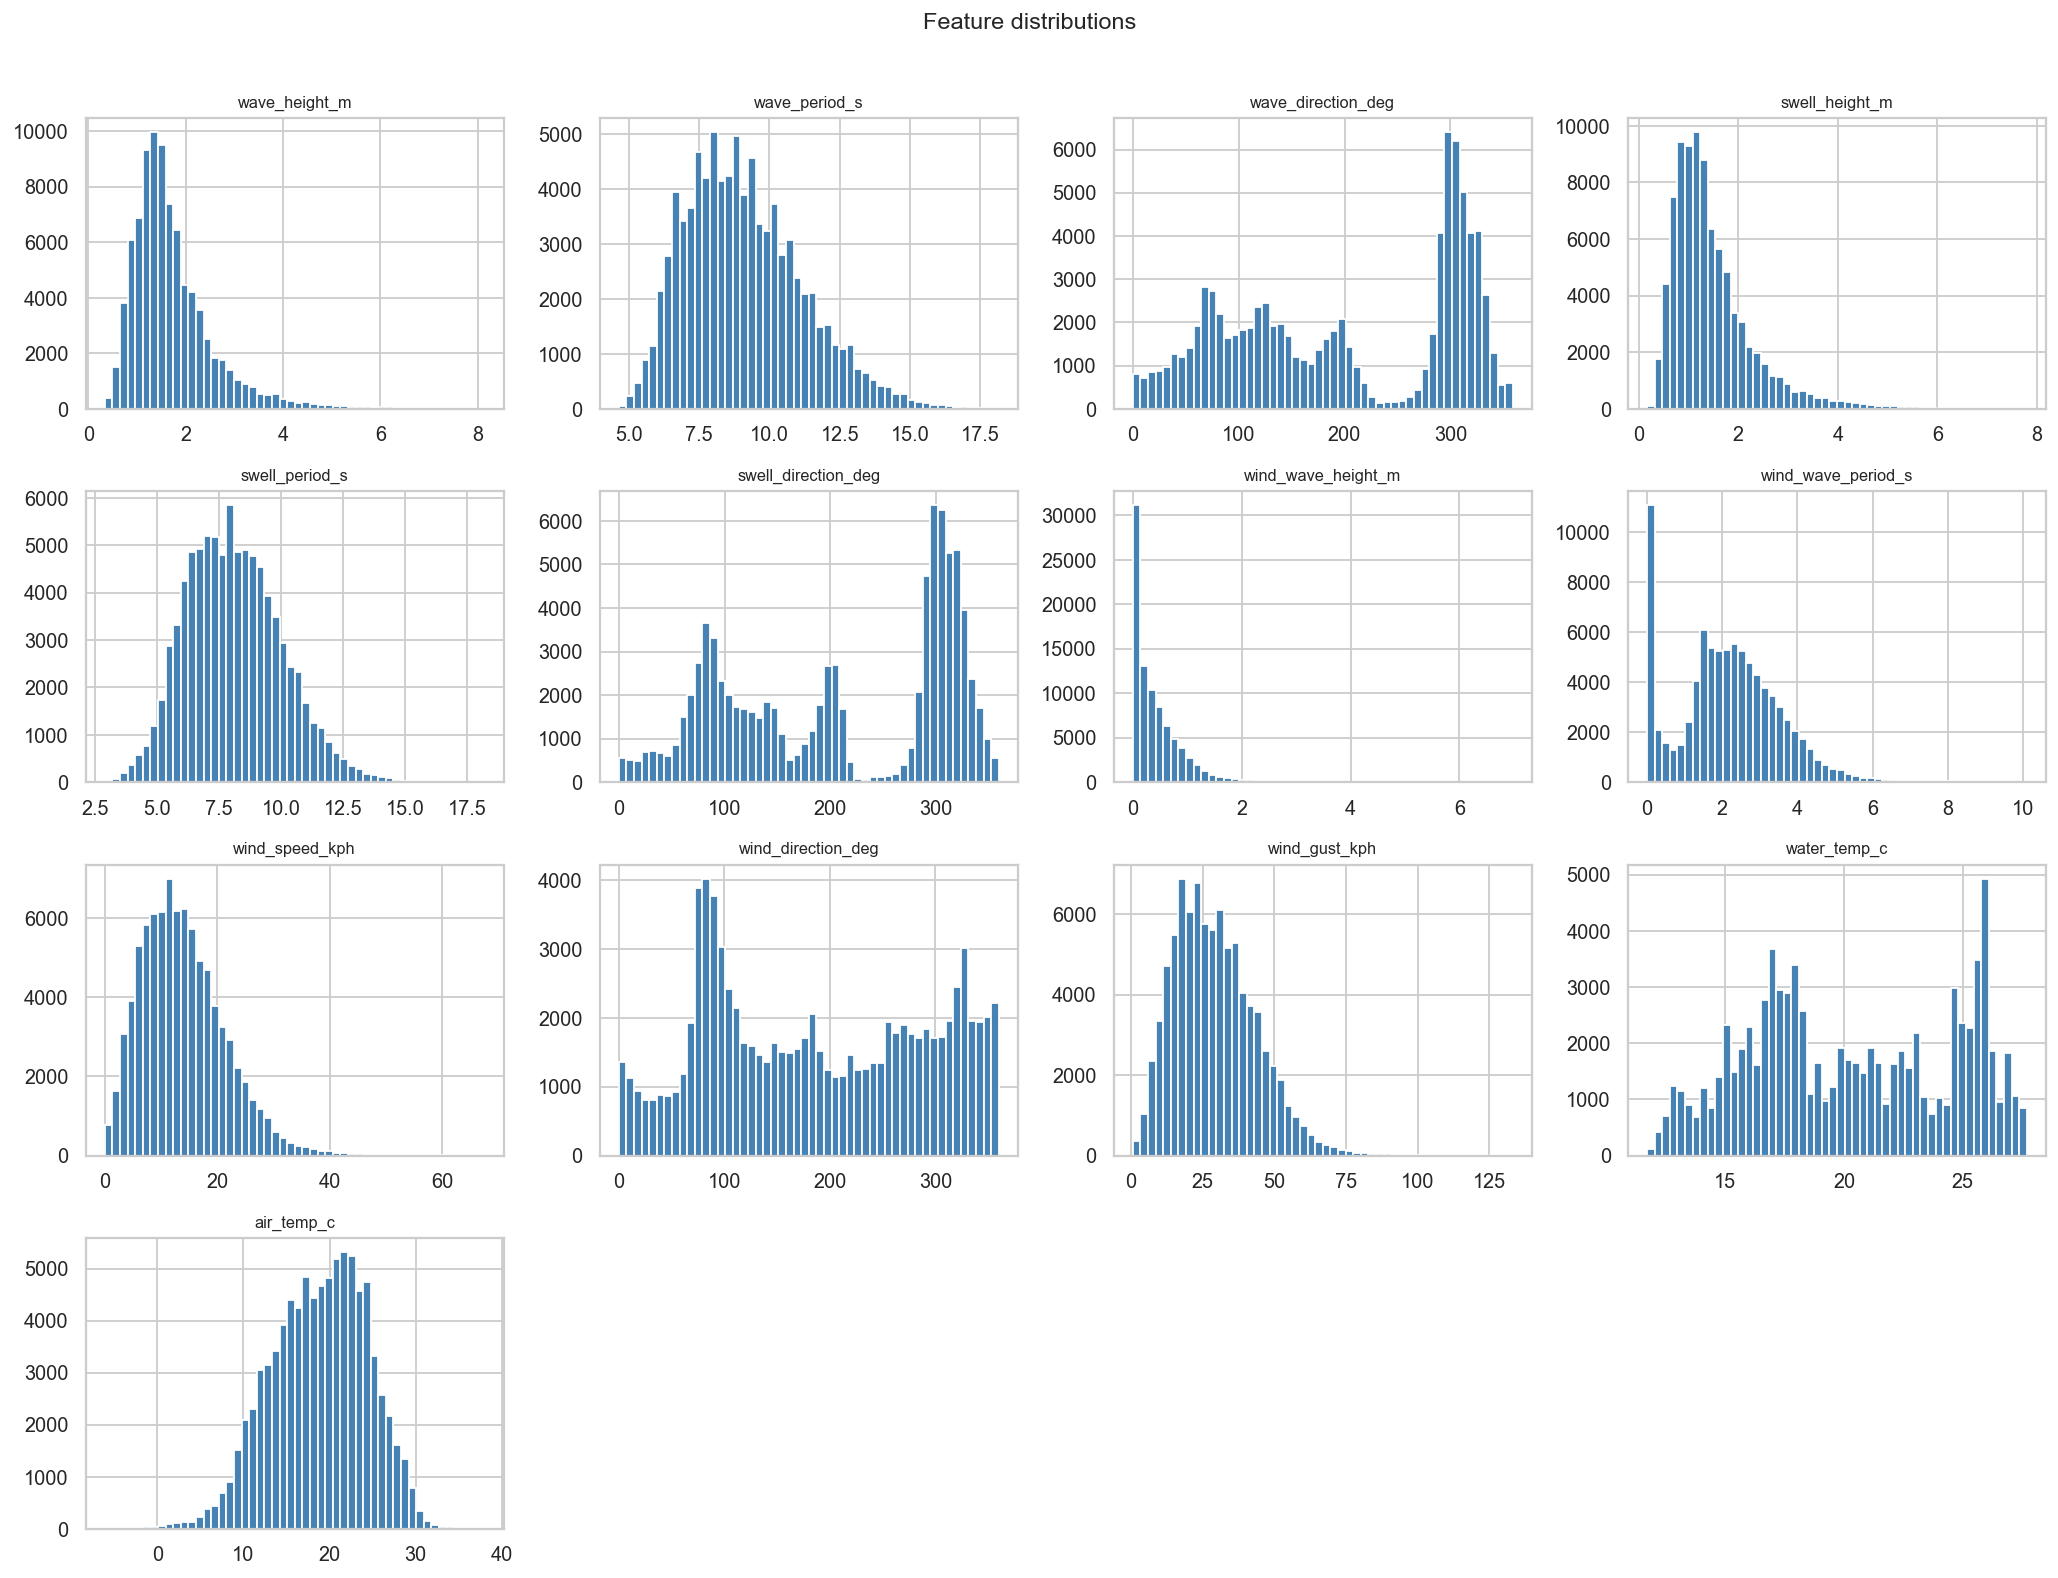

In [8]:
numeric_features = [
    "wave_height_m", "wave_period_s", "wave_direction_deg",
    "swell_height_m", "swell_period_s", "swell_direction_deg",
    "wind_wave_height_m", "wind_wave_period_s",
    "wind_speed_kph", "wind_direction_deg", "wind_gust_kph",
    "water_temp_c", "air_temp_c",
]

n_cols = 4
n_rows = (len(numeric_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col].dropna(), bins=50, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature distributions", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "feature_distributions.png", bbox_inches="tight")
plt.show()

Spots with water_temp_c > 25°C:
['pipeline', 'gold_coast', 'hossegor']

Counts per spot:
spot_id
pipeline      13048
gold_coast     4827
hossegor          4


## 6. Correlation heatmap

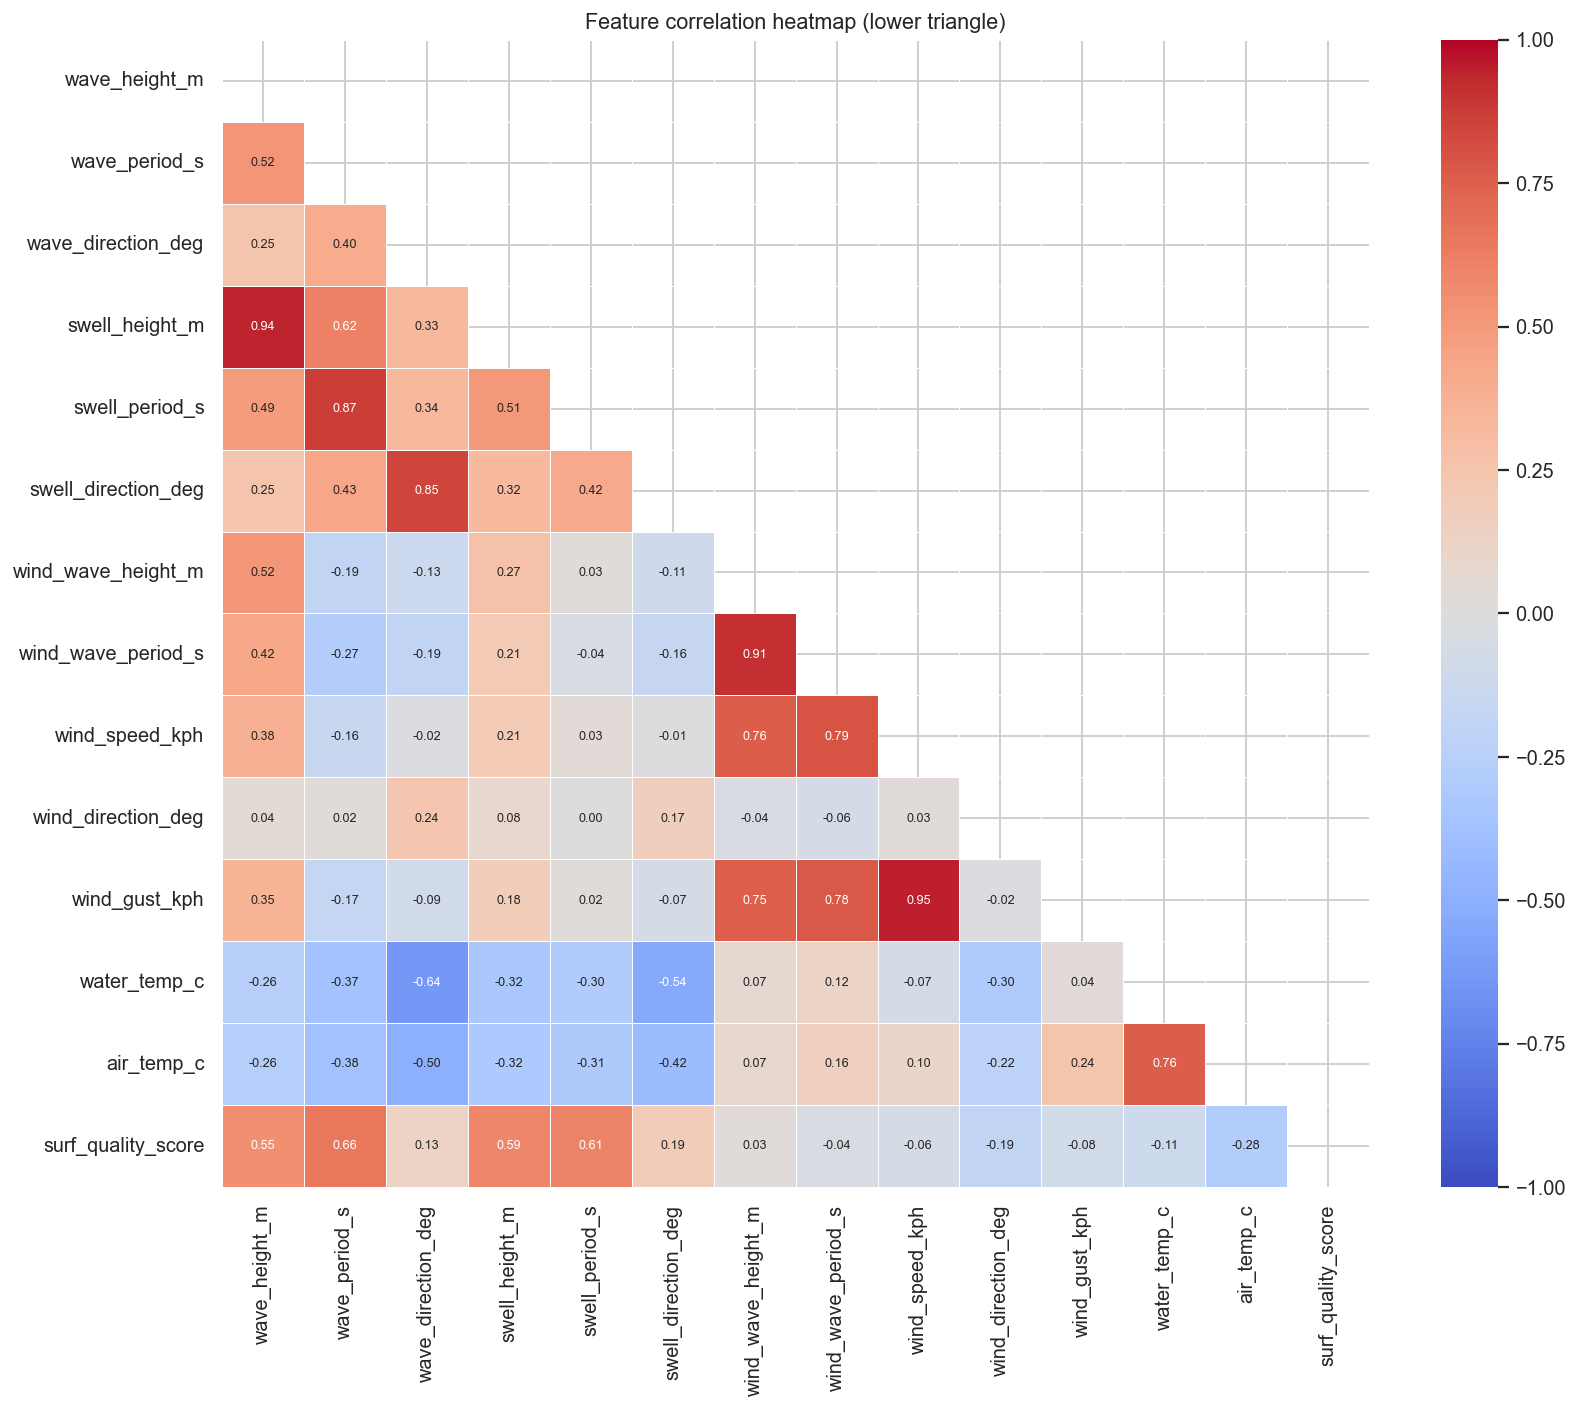

In [9]:
corr_cols = numeric_features + ["surf_quality_score"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax, annot_kws={"size": 7}
)
ax.set_title("Feature correlation heatmap (lower triangle)")
plt.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 7. Target-vs-feature scatter (top candidates by |correlation|)

Features ranked by |correlation with surf_quality_score|:
wave_period_s          0.655
swell_period_s         0.608
swell_height_m         0.594
wave_height_m          0.553
air_temp_c             0.280
swell_direction_deg    0.189
wind_direction_deg     0.189
wave_direction_deg     0.130
water_temp_c           0.110
wind_gust_kph          0.079
wind_speed_kph         0.056
wind_wave_period_s     0.042
wind_wave_height_m     0.030


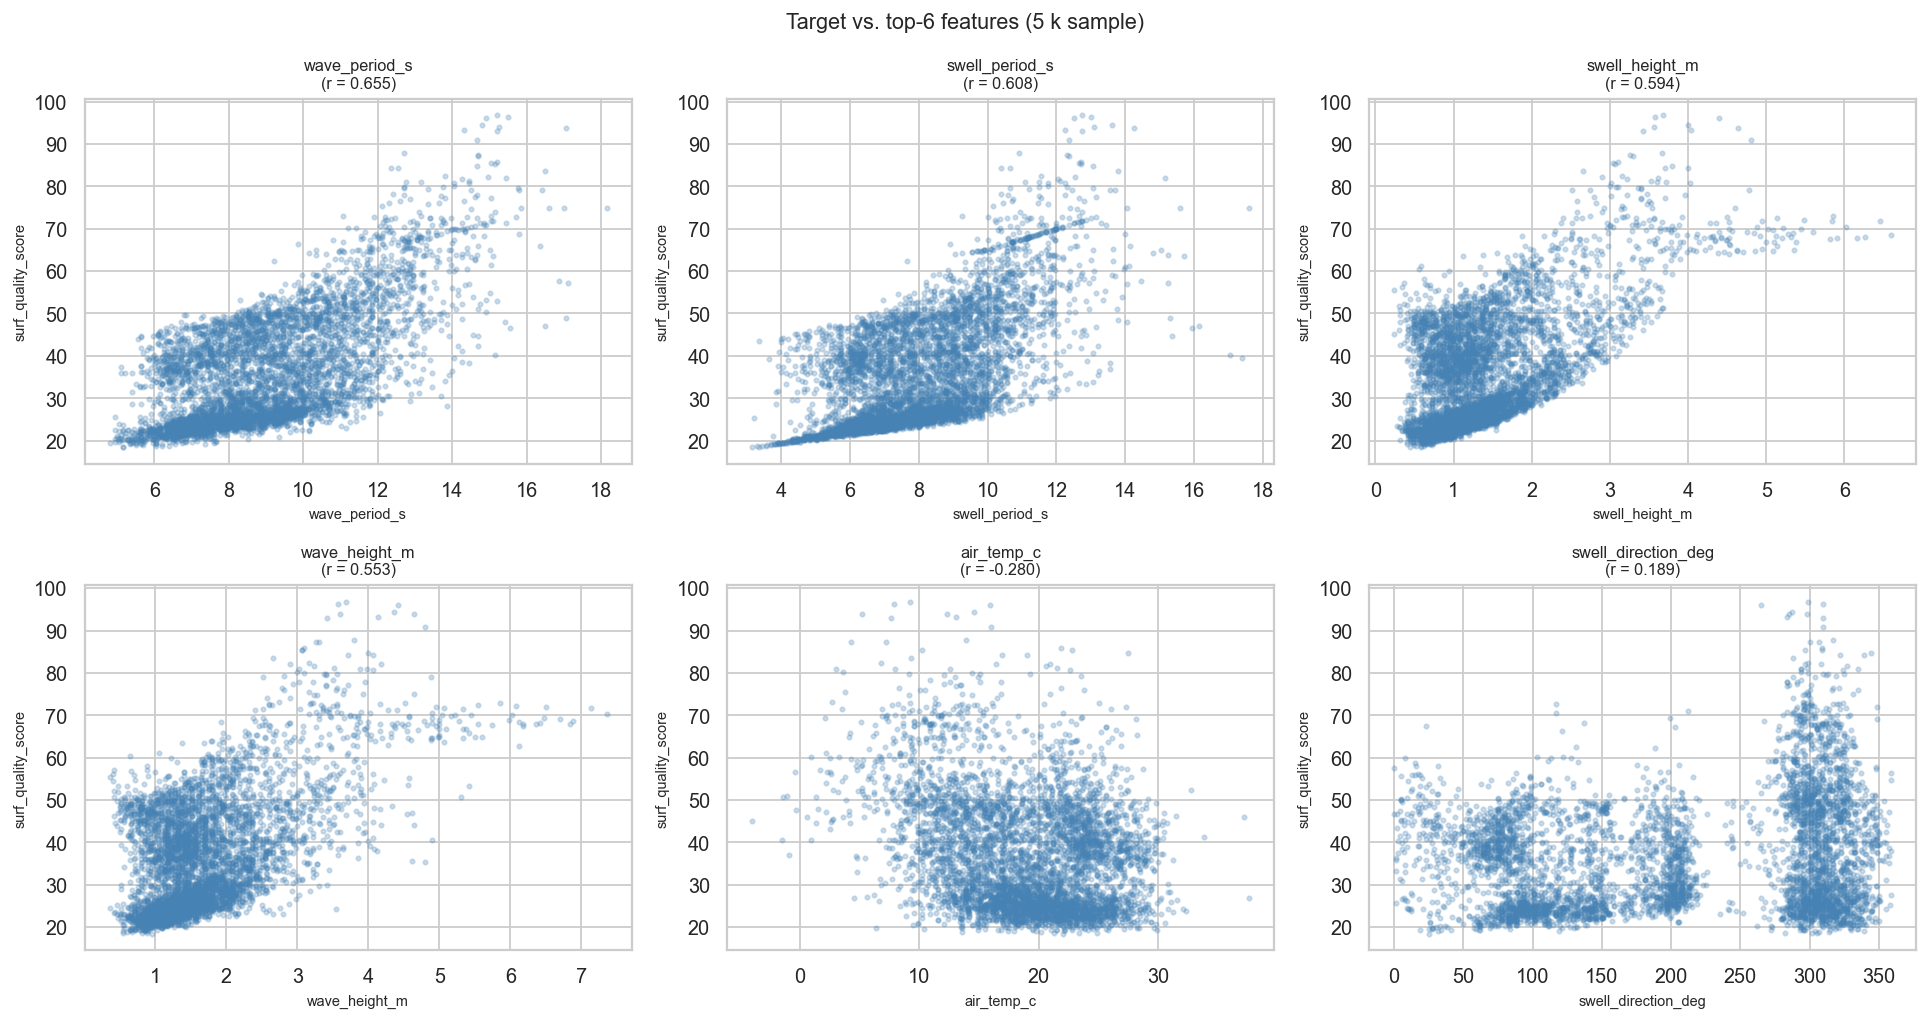

In [10]:
target_corr = corr["surf_quality_score"].drop("surf_quality_score").abs().sort_values(ascending=False)
print("Features ranked by |correlation with surf_quality_score|:")
print(target_corr.round(3).to_string())

top_features = target_corr.head(6).index.tolist()

sample = df.sample(5000, random_state=SEED)  # down-sample for readability

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(
        sample[feat], sample["surf_quality_score"],
        alpha=0.25, s=6, color="steelblue"
    )
    r = corr.loc[feat, "surf_quality_score"]
    axes[i].set_title(f"{feat}\n(r = {r:.3f})", fontsize=9)
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel("surf_quality_score", fontsize=8)

fig.suptitle("Target vs. top-6 features (5 k sample)", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "target_vs_features.png", bbox_inches="tight")
plt.show()

## 8. Summary

In [11]:
saved = sorted(FIG_DIR.glob("*.png"))
print(f"Figures written to {FIG_DIR.resolve()}:")
for f in saved:
    print(" ", f.name)

print()
print(f"Total rows       : {len(df):,}")
print(f"Spots            : {df['spot_id'].nunique()}")
print(f"Date range       : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Label mean±std   : {target.mean():.1f} ± {target.std():.1f}")
print(f"Tide NaN rate    : {df['tide_height_m'].isna().mean()*100:.0f}%  (imputed to per-spot preferred during training)")

Figures written to /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/eda:
  correlation_heatmap.png
  feature_distributions.png
  label_distribution.png
  missing_values.png
  sample_counts.png
  target_vs_features.png

Total rows       : 87,720
Spots            : 5
Date range       : 2024-04-25 → 2026-04-25
Label mean±std   : 37.2 ± 13.0
Tide NaN rate    : 100%  (imputed to per-spot preferred during training)
